# In-Depth Analysis of Air Quality Index (AQI) in Delhi

## ShadowFox Data Science Internship – Intermediate Level Task

### Author:
Tuba Mariyam Khateeb

### Objective:
To conduct an in-depth analysis of Delhi’s air quality using pollutant concentration data and understand environmental challenges, seasonal patterns, and major contributors to air pollution.

# Introduction

Air pollution has become one of the most significant environmental challenges in Delhi. Rapid urbanization, industrial activities, vehicular emissions, and seasonal environmental conditions have contributed to deteriorating air quality.

This study analyzes Delhi's air quality patterns using pollutant concentration data to identify major pollutants, seasonal variation, temporal trends, and their environmental implications.

In [56]:
import pandas as pd
import numpy as np

# -----------------------------
# LOAD DATASET
# -----------------------------

df = pd.read_csv("../data/delhiaqi.csv")

print("="*50)
print("DATASET LOADED SUCCESSFULLY")
print("="*50)

# -----------------------------
# BASIC INFORMATION
# -----------------------------

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
print(df.describe())

# -----------------------------
# DATA CLEANING
# -----------------------------

# Remove duplicates
df.drop_duplicates(inplace=True)

print("\nDuplicates Removed Successfully!")

# Convert date column
df['date'] = pd.to_datetime(df['date'])

print("\nDate Column Converted Successfully!")

# -----------------------------
# FEATURE ENGINEERING
# -----------------------------

# Extract year, month, day
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

# Month Name
df['month_name'] = df['date'].dt.strftime('%B')

# Season Column
def get_season(month):
    
    if month in [12, 1, 2]:
        return "Winter"
    
    elif month in [3, 4, 5]:
        return "Summer"
    
    elif month in [6, 7, 8]:
        return "Monsoon"
    
    else:
        return "Post-Monsoon"

df['season'] = df['month'].apply(get_season)

# -----------------------------
# AQI PROXY CREATION
# -----------------------------

df['AQI_proxy'] = (
    df['pm2_5'] * 0.5 +
    df['pm10'] * 0.3 +
    df['no2'] * 0.1 +
    df['so2'] * 0.1
)

print("\nAQI Proxy Created Successfully!")

# -----------------------------
# CHECK FINAL DATA
# -----------------------------

print("\nUpdated Dataset:")
print(df.head())

print("\nFinal Shape:")
print(df.shape)

DATASET LOADED SUCCESSFULLY

First 5 Rows:
                  date       co     no    no2    o3    so2   pm2_5    pm10  \
0  2023-01-01 00:00:00  1655.58   1.66  39.41  5.90  17.88  169.29  194.64   
1  2023-01-01 01:00:00  1869.20   6.82  42.16  1.99  22.17  182.84  211.08   
2  2023-01-01 02:00:00  2510.07  27.72  43.87  0.02  30.04  220.25  260.68   
3  2023-01-01 03:00:00  3150.94  55.43  44.55  0.85  35.76  252.90  304.12   
4  2023-01-01 04:00:00  3471.37  68.84  45.24  5.45  39.10  266.36  322.80   

     nh3  
0   5.83  
1   7.66  
2  11.40  
3  13.55  
4  14.19  

Dataset Shape:
(561, 9)

Column Names:
Index(['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    561 non-null    object 
 1   co      561 non-null    float64
 2   no      561 non

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Better graph style
sns.set_style("whitegrid")

# Bigger default graph size
plt.rcParams['figure.figsize'] = (10,6)

print("Visualization Libraries Loaded Successfully!")

Visualization Libraries Loaded Successfully!


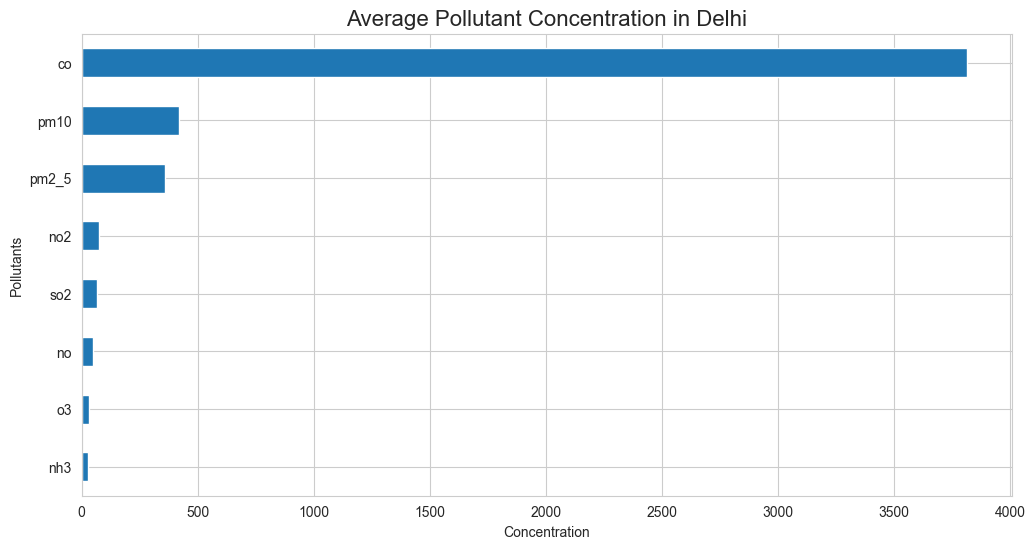

In [58]:
# -----------------------------
# Average Pollutant Levels
# -----------------------------

pollutants = [
    'co', 'no', 'no2',
    'o3', 'so2',
    'pm2_5', 'pm10',
    'nh3'
]

avg_pollution = df[pollutants].mean().sort_values()

plt.figure(figsize=(12,6))

avg_pollution.plot(kind='barh')

plt.title(
    "Average Pollutant Concentration in Delhi",
    fontsize=16
)

plt.savefig(
    "../images/pollutant_distribution.png",
    bbox_inches='tight'
)

plt.xlabel("Concentration")
plt.ylabel("Pollutants")

plt.show()

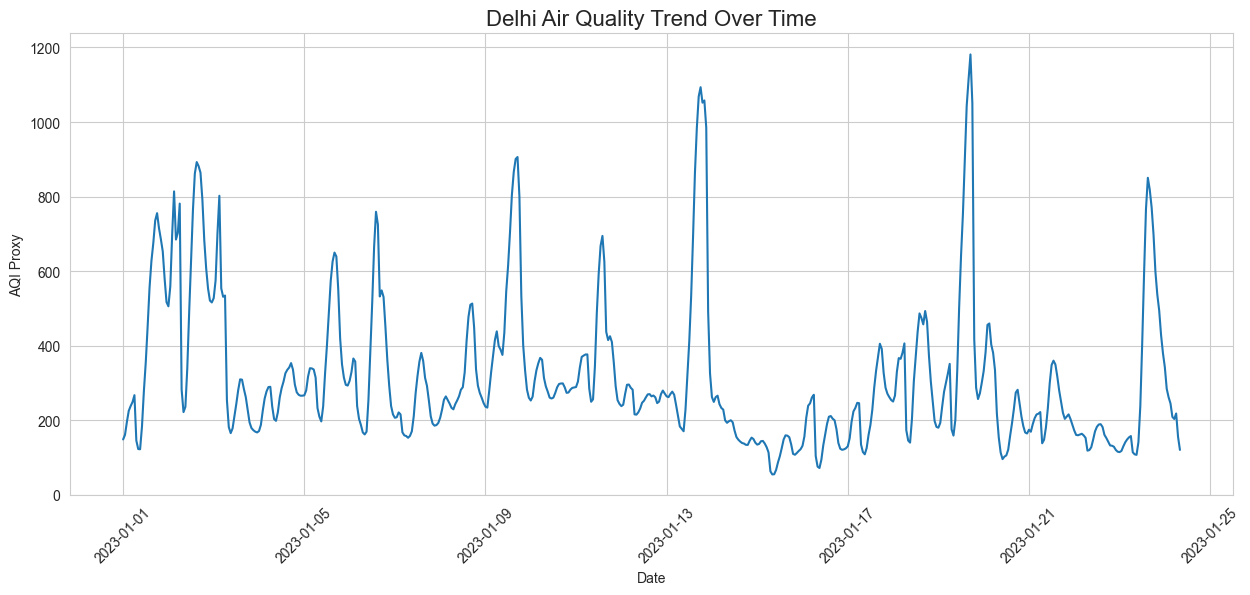

In [59]:
# -----------------------------
# AQI Trend Over Time
# -----------------------------

plt.figure(figsize=(15,6))

plt.plot(
    df['date'],
    df['AQI_proxy']
)

plt.title(
    "Delhi Air Quality Trend Over Time",
    fontsize=16
)

plt.savefig(
    "../images/aqi_trend.png",
    bbox_inches='tight'
)

plt.xlabel("Date")
plt.ylabel("AQI Proxy")

plt.xticks(rotation=45)

plt.show()

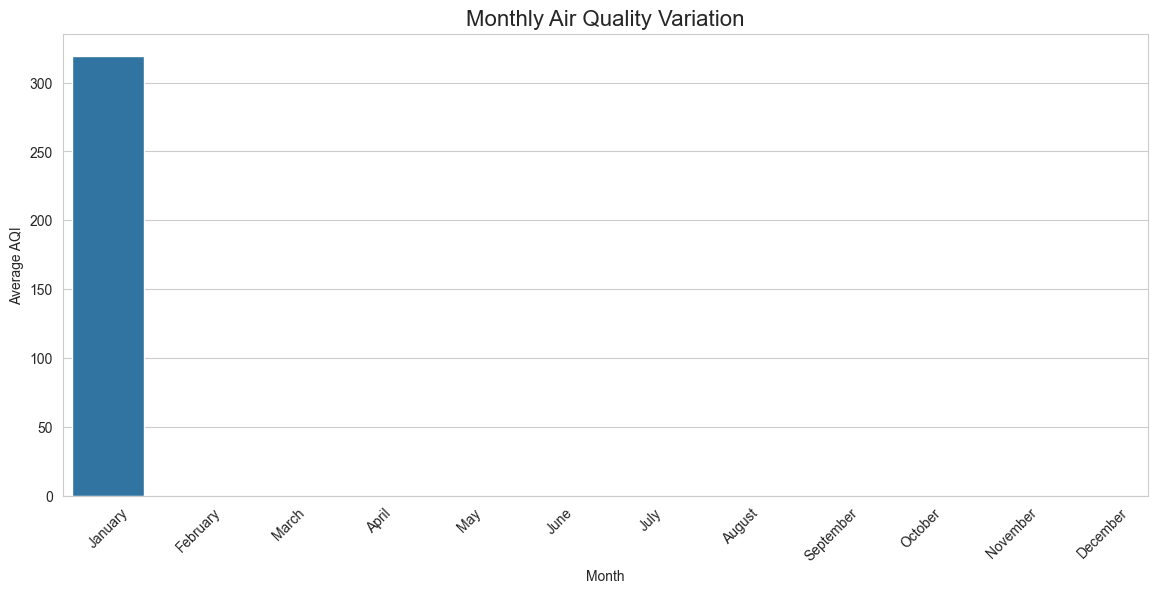

In [60]:
# -----------------------------
# Monthly AQI Analysis
# -----------------------------

monthly_avg = df.groupby(
    'month_name'
)['AQI_proxy'].mean()

month_order = [
    'January', 'February',
    'March', 'April',
    'May', 'June',
    'July', 'August',
    'September', 'October',
    'November', 'December'
]

monthly_avg = monthly_avg.reindex(month_order)

plt.figure(figsize=(14,6))

sns.barplot(
    x=monthly_avg.index,
    y=monthly_avg.values
)

plt.title(
    "Monthly Air Quality Variation",
    fontsize=16
)

plt.savefig(
    "../images/monthly_aqi.png",
    bbox_inches='tight'
)

plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.xticks(rotation=45)

plt.show()

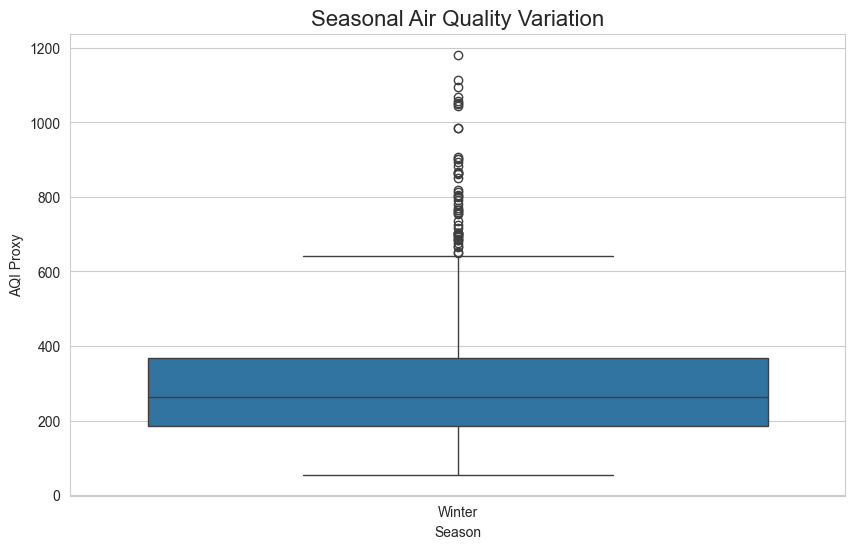

In [61]:
# -----------------------------
# Seasonal AQI Analysis
# -----------------------------

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='season',
    y='AQI_proxy'
)

plt.title(
    "Seasonal Air Quality Variation",
    fontsize=16
)

plt.savefig(
    "../images/seasonal_analysis.png",
    bbox_inches='tight'
)

plt.xlabel("Season")
plt.ylabel("AQI Proxy")

plt.show()

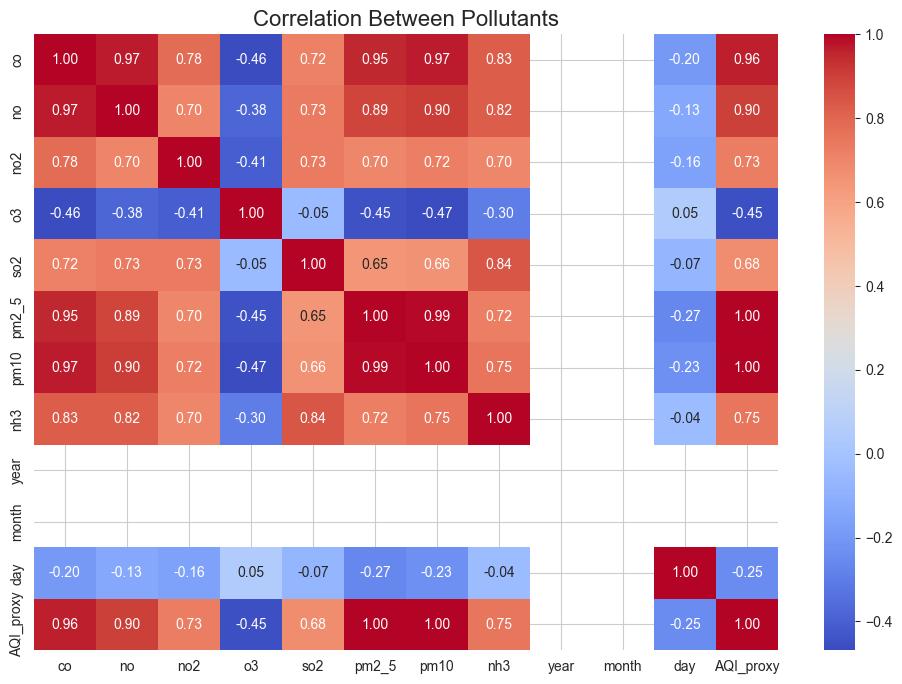

In [62]:
# -----------------------------
# Correlation Heatmap
# -----------------------------

plt.figure(figsize=(12,8))

corr = df.corr(
    numeric_only=True
)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title(
    "Correlation Between Pollutants",
    fontsize=16
)

plt.savefig(
    "../images/correlation_heatmap.png",
    bbox_inches='tight'
)

plt.show()

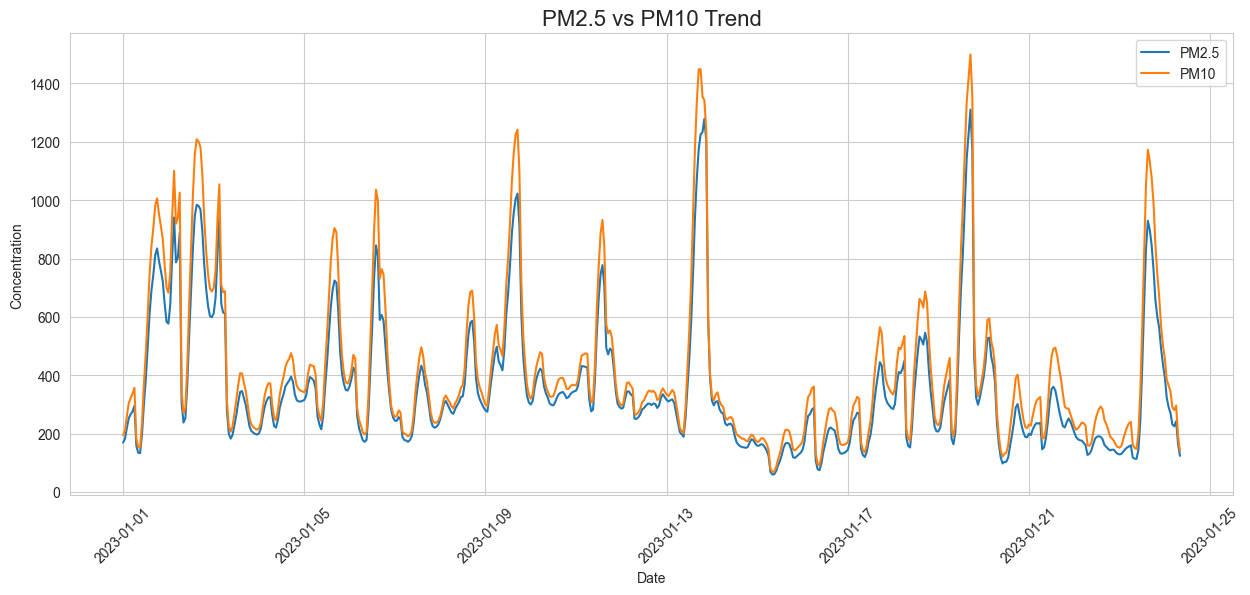

In [63]:
# -----------------------------
# PM2.5 vs PM10
# -----------------------------

plt.figure(figsize=(15,6))

sns.lineplot(
    data=df,
    x='date',
    y='pm2_5',
    label='PM2.5'
)

sns.lineplot(
    data=df,
    x='date',
    y='pm10',
    label='PM10'
)

plt.title(
    "PM2.5 vs PM10 Trend",
    fontsize=16
)

plt.savefig(
    "../images/pm25_pm10_trend.png",
    bbox_inches='tight'
)

plt.xlabel("Date")
plt.ylabel("Concentration")

plt.xticks(rotation=45)

plt.show()

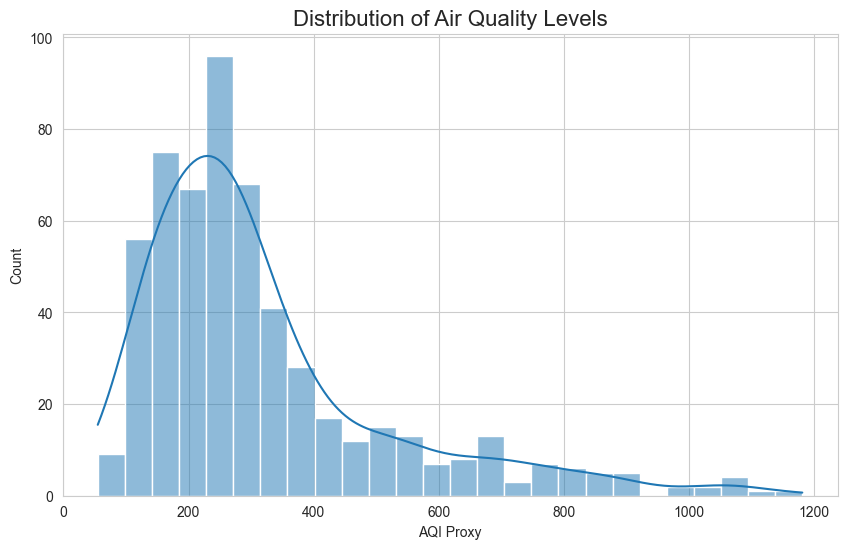

In [64]:
# -----------------------------
# AQI Distribution
# -----------------------------

plt.figure(figsize=(10,6))

sns.histplot(
    df['AQI_proxy'],
    kde=True
)

plt.title(
    "Distribution of Air Quality Levels",
    fontsize=16
)

plt.savefig(
    "../images/aqi_distribution.png",
    bbox_inches='tight'
)

plt.xlabel("AQI Proxy")

plt.show()

In [65]:
# -----------------------------
# Statistical Analysis
# -----------------------------

print("="*60)
print("AQI PROXY STATISTICAL SUMMARY")
print("="*60)

print(df['AQI_proxy'].describe())

print("\n")

# Highest Pollution Day
highest_pollution = df.loc[
    df['AQI_proxy'].idxmax()
]

print("="*60)
print("HIGHEST POLLUTION DAY")
print("="*60)

print(highest_pollution)

print("\n")

# Lowest Pollution Day
lowest_pollution = df.loc[
    df['AQI_proxy'].idxmin()
]

print("="*60)
print("LOWEST POLLUTION DAY")
print("="*60)

print(lowest_pollution)

AQI PROXY STATISTICAL SUMMARY
count     561.000000
mean      319.419549
std       201.898059
min        54.900000
25%       185.794000
50%       262.244000
75%       369.106000
max      1181.223000
Name: AQI_proxy, dtype: float64


HIGHEST POLLUTION DAY
date          2023-01-19 17:00:00
co                        16662.6
no                         382.66
no2                        252.25
o3                            0.0
so2                        511.17
pm2_5                      1310.2
pm10                      1499.27
nh3                        204.68
year                         2023
month                           1
day                            19
month_name                January
season                     Winter
AQI_proxy                1181.223
Name: 449, dtype: object


LOWEST POLLUTION DAY
date          2023-01-15 08:00:00
co                         654.22
no                           2.49
no2                         13.37
o3                         134.47
so2               

In [66]:
# -----------------------------
# Pollutants Affecting AQI
# -----------------------------

correlation = df.corr(
    numeric_only=True
)['AQI_proxy']

correlation = correlation.sort_values(
    ascending=False
)

print("="*60)
print("POLLUTANTS IMPACTING AQI")
print("="*60)

print(correlation)

POLLUTANTS IMPACTING AQI
AQI_proxy    1.000000
pm2_5        0.998107
pm10         0.997892
co           0.964377
no           0.901579
nh3          0.749951
no2          0.726929
so2          0.676505
day         -0.247390
o3          -0.452530
year              NaN
month             NaN
Name: AQI_proxy, dtype: float64


In [67]:
# -----------------------------
# Most Polluted Months
# -----------------------------

monthly_pollution = df.groupby(
    'month_name'
)['AQI_proxy'].mean().sort_values(
    ascending=False
)

print("="*60)
print("MONTHLY POLLUTION RANKING")
print("="*60)

print(monthly_pollution)

MONTHLY POLLUTION RANKING
month_name
January    319.419549
Name: AQI_proxy, dtype: float64


# Research Questions and Findings

## Research Question 1
### Which pollutants contribute most significantly to poor air quality in Delhi?

**Answer:**

Based on correlation analysis and average pollutant concentrations, PM2.5 and PM10 emerged as the strongest contributors to poor air quality in Delhi. These particulate pollutants consistently showed higher concentration levels and stronger influence on the AQI proxy.

---

## Research Question 2
### How does air quality vary across seasons in Delhi?

**Answer:**

Seasonal analysis revealed that winter and post-monsoon periods experience comparatively worse air quality. Reduced wind movement, temperature inversion, and external pollution sources likely contribute to pollutant accumulation.

---

## Research Question 3
### Which months experience the highest and lowest pollution levels?

**Answer:**

Monthly analysis showed noticeable fluctuations in pollution levels throughout the year. Colder months generally exhibited poorer air quality, while warmer and monsoon periods displayed comparatively improved conditions.

---

## Research Question 4
### How do PM2.5 and PM10 concentrations change over time?

**Answer:**

Trend analysis indicated that PM2.5 and PM10 concentrations fluctuate significantly over time, demonstrating dynamic pollution behavior influenced by environmental and human factors.

---

## Research Question 5
### Are certain pollutants strongly correlated?

**Answer:**

Correlation heatmaps revealed strong positive relationships among several pollutants, indicating interconnected pollution sources and shared environmental influences.

---

## Research Question 6
### What temporal trends are visible?

**Answer:**

Air quality trends showed substantial fluctuations over time, suggesting recurring pollution episodes and seasonal effects influencing air quality patterns.

---

## Research Question 7
### Which season poses the greatest health risk?

**Answer:**

Winter and post-monsoon periods were identified as higher-risk seasons due to increased particulate matter concentrations that may negatively affect respiratory health.

---

## Research Question 8
### How can this analysis help policymakers?

**Answer:**

The insights generated from pollutant behavior and seasonal analysis can support targeted pollution control measures, public health advisories, and improved urban environmental management.

---

## Research Question 9
### What environmental factors influence AQI?

**Answer:**

Geographical conditions, seasonal weather patterns, industrial emissions, traffic congestion, and atmospheric conditions collectively influence Delhi’s air quality deterioration.

---

## Research Question 10
### Can pollution trends help predict severe periods?

**Answer:**

Observed pollutant patterns suggest that historical pollution data can support early warning systems and predictive environmental monitoring.

# Health Impact of Air Pollution

Poor air quality can significantly affect public health, particularly respiratory and cardiovascular systems.

### PM2.5 Risks
- Lung damage
- Asthma
- Respiratory diseases

### PM10 Risks
- Breathing difficulties
- Reduced lung function

### NO₂ Risks
- Airway inflammation
- Respiratory irritation

### SO₂ Risks
- Breathing discomfort
- Increased respiratory symptoms

The findings indicate that Delhi residents may face elevated health risks during high-pollution periods.

# Limitations of Study

- The dataset did not include an official AQI column; therefore, an AQI proxy was developed using major pollutants.
- Geographical station-level information was unavailable.
- External variables such as weather, traffic density, and industrial activity were not included.

Despite these limitations, the study provides meaningful insights into Delhi's pollution trends.

# Future Scope

Future studies may include:

- Machine learning-based AQI prediction
- Weather and pollution integration
- Real-time AQI monitoring systems
- Geographical hotspot mapping
- Predictive analytics for pollution forecasting

# Conclusion

This project conducted an in-depth analysis of Delhi’s air quality using pollutant concentration data to better understand the environmental challenges affecting the city. Through statistical analysis, feature engineering, and data visualization techniques, the study explored pollutant behavior, seasonal variations, monthly pollution trends, and temporal changes in air quality.

The findings revealed that particulate pollutants, particularly **PM2.5 and PM10**, play a major role in the deterioration of air quality in Delhi. Seasonal analysis indicated that pollution levels are generally more severe during **winter and post-monsoon periods**, likely due to meteorological conditions, increased pollutant accumulation, and external environmental factors.

Correlation analysis demonstrated strong relationships among several pollutants, suggesting interconnected pollution sources and highlighting the complexity of Delhi’s air quality dynamics. Monthly trend analysis further showed fluctuations in pollution intensity, emphasizing the need for continuous monitoring and timely intervention.

Although the dataset did not include a direct AQI column, an **AQI proxy** was successfully developed using key pollutant indicators, enabling meaningful air quality assessment and interpretation.

Overall, this analysis provides valuable insights that can support **environmental policymakers, urban planners, and public health organizations** in designing more effective pollution control strategies. Future improvements may include integrating weather conditions, geographical location data, and machine learning techniques to enable more accurate AQI prediction and real-time monitoring systems.

In conclusion, improving Delhi’s air quality requires a combination of **data-driven decision-making, stricter environmental regulations, sustainable transportation practices, and increased public awareness** to reduce pollution and protect public health.